In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import tqdm

In [6]:
import transformer_lens

# Load a model (eg GPT-2 Small)
model = transformer_lens.HookedTransformer.from_pretrained("pythia-70m")
# model = transformer_lens.HookedTransformer.from_pretrained("gpt2-small")

Loaded pretrained model pythia-70m into HookedTransformer


In [7]:
# generate text
output = model.generate("Barack Obama is the 44th president of the United States. His term lasted from 2008 until ", max_new_tokens=20)
print(output)

100%|██████████| 20/20 [00:01<00:00, 19.23it/s]

Barack Obama is the 44th president of the United States. His term lasted from 2008 until 
2015.

USA TODAY

Born 3 September 2012

Washington D.C.


In [8]:
# Run the model and get logits and activations
# logits, cache = model.run_with_cache("The cat sat on the mat")
logits, cache = model.run_with_cache("The cat sat on the mat", names_filter='blocks.3.hook_resid_post')

In [9]:
cache['blocks.3.hook_resid_post']

tensor([[[ 0.0099,  0.6871, -0.0311,  ...,  0.1835, -0.5690,  1.6467],
         [-0.1242,  0.5637,  0.0151,  ...,  0.8597, -0.3058, -0.0499],
         [ 0.1589,  0.1767,  0.3642,  ...,  0.1531, -0.0519,  0.0056],
         ...,
         [ 0.2528,  0.1811,  0.3149,  ...,  0.3647, -0.3278,  1.0852],
         [ 0.0978, -0.3465, -0.1512,  ...,  0.4026, -0.4208,  0.2968],
         [-0.3267,  0.1939,  0.0915,  ..., -0.4381, -0.1126,  0.4266]]],
       device='mps:0')

In [10]:
print(cache.keys())

dict_keys(['blocks.3.hook_resid_post'])


In [10]:
d = cache['blocks.3.hook_resid_post'].shape[-1]

m = d * 8

W_enc = torch.nn.init.xavier_normal_(torch.empty(d, m))
b_pre = torch.zeros(d)
b_enc = torch.zeros(m)
W_dec = torch.nn.init.xavier_normal_(torch.empty(m, d))

W_dec = W_dec / W_dec.norm(dim=1, keepdim=True)

def SAE(x, b_pre=b_pre, b_enc=b_enc, W_enc=W_enc):
    x = x - b_pre
    x = x @ W_enc
    x = x + b_enc
    return F.relu(x)

def decode(f, b_pre=b_pre, W_dec=W_dec):
    xhat = f @ W_dec
    xhat = xhat + b_pre
    return xhat

def loss(xhat, x, f, lam=1e-3):
    return F.mse_loss(xhat, x) + lam * f.abs().mean()


x = cache['blocks.3.hook_resid_post'][0, :, :].cpu()
print(x.shape)

f = SAE(x)
xhat = decode(f)
loss_val = loss(xhat, x, f)

loss_val

torch.Size([7, 512])


tensor(8.6341)

In [11]:
def SAEloss(xhat, x, f, lam=1e-3):
    return F.mse_loss(xhat, x) + lam * f.abs().mean()

class SparseAutoEncoder(nn.Module):
    def __init__(self, d, m):
        super().__init__()
        self.b_pre = nn.Parameter(torch.zeros(d))
        self.b_enc = nn.Parameter(torch.zeros(m))
        self.W_enc = nn.Parameter(torch.nn.init.xavier_normal_(torch.empty(d,m)))
        self.W_dec = nn.Parameter(torch.nn.init.xavier_normal_(torch.empty(m,d)))
        self.W_dec = nn.Parameter(self.W_dec / self.W_dec.norm(dim=1, keepdim=True))
        
        self.act = nn.ReLU()
        
    def encoder(self, x):
        x = x - self.b_pre
        x = x @ self.W_enc
        x = x + self.b_enc
        x = self.act(x)
        return x
    
    def decoder(self, f):
        xhat = f @ self.W_dec
        xhat = xhat + self.b_pre
        return xhat
    
    def forward(self, x):
        f = self.encoder(x)
        xhat = self.decoder(f)
        return xhat, f

In [12]:
df = pd.read_csv("yoda.csv")
df.head()

,text
0,"The very Republic is threatened, if involved t..."
1,"Hard to see, the dark side is. Discover who th..."
2,"With this Naboo queen you must stay, Qui-Gon. ..."
3,May the Force be with you.
4,(Cont'd) Master Qui-Gon more to say have you?


In [13]:
all_activations = []
with torch.no_grad():
    for text in df.text:
        # logits, cache = model.run_with_cache(text)
        logits, cache = model.run_with_cache(text, names_filter='blocks.3.hook_resid_post')
        acts = cache['blocks.3.hook_resid_post'][0].cpu()  # (seq_len, 512)
        all_activations.append(acts)
        del cache  # free the full cache immediately
# all_activations = torch.tensor([all_activations])

In [14]:
# convert all_activations to a single tensor of shape (num_samples, seq_len, d)
all_activations = torch.cat(all_activations, dim=0)
print(all_activations.shape)  # should be (num_samples, seq_len, d

torch.Size([1837, 512])


In [15]:
1837 // 128

14

In [16]:
# randomly sample 128 activations from all_activations
sampled_activations = all_activations[torch.randperm(all_activations.shape[0])[:128]]
print(sampled_activations.shape)  # should be (128, d)

torch.Size([128, 512])


In [18]:
d = all_activations.shape[-1]
m = d * 8
learning_rate = 3e-4
batch_size = 128

SAE = SparseAutoEncoder(d=d, m=m)
optimizer = torch.optim.Adam(SAE.parameters(), lr=learning_rate)

metrics = {
    'mse': [],
    'l1': [],
    'l0': [],
    'loss': []
}

for i in range(30):
    # x = cache['blocks.3.hook_resid_post'][0, :, :].cpu()
    x = all_activations[torch.randperm(all_activations.shape[0])[:batch_size]].cpu()
    xhat, f = SAE(x)
    
    mse = F.mse_loss(xhat, x)
    l1 = f.abs().mean()
    l0 = (f.abs() > 0).float().mean()
    loss = SAEloss(xhat, x, f)
    
    metrics['mse'].append(mse.item())
    metrics['l1'].append(l1.item())
    metrics['l0'].append(l0.item())
    metrics['loss'].append(loss.item())
    
    if i % 5 == 0:
        print(f"loss at step {i}: {loss}")
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        SAE.W_dec.data = SAE.W_dec.data / SAE.W_dec.data.norm(dim=1, keepdim=True)

loss at step 0: 5.396002769470215
loss at step 5: 1.4395272731781006
loss at step 10: 0.574921190738678
loss at step 15: 0.3056280314922333
loss at step 20: 0.35345298051834106
loss at step 25: 0.19012585282325745


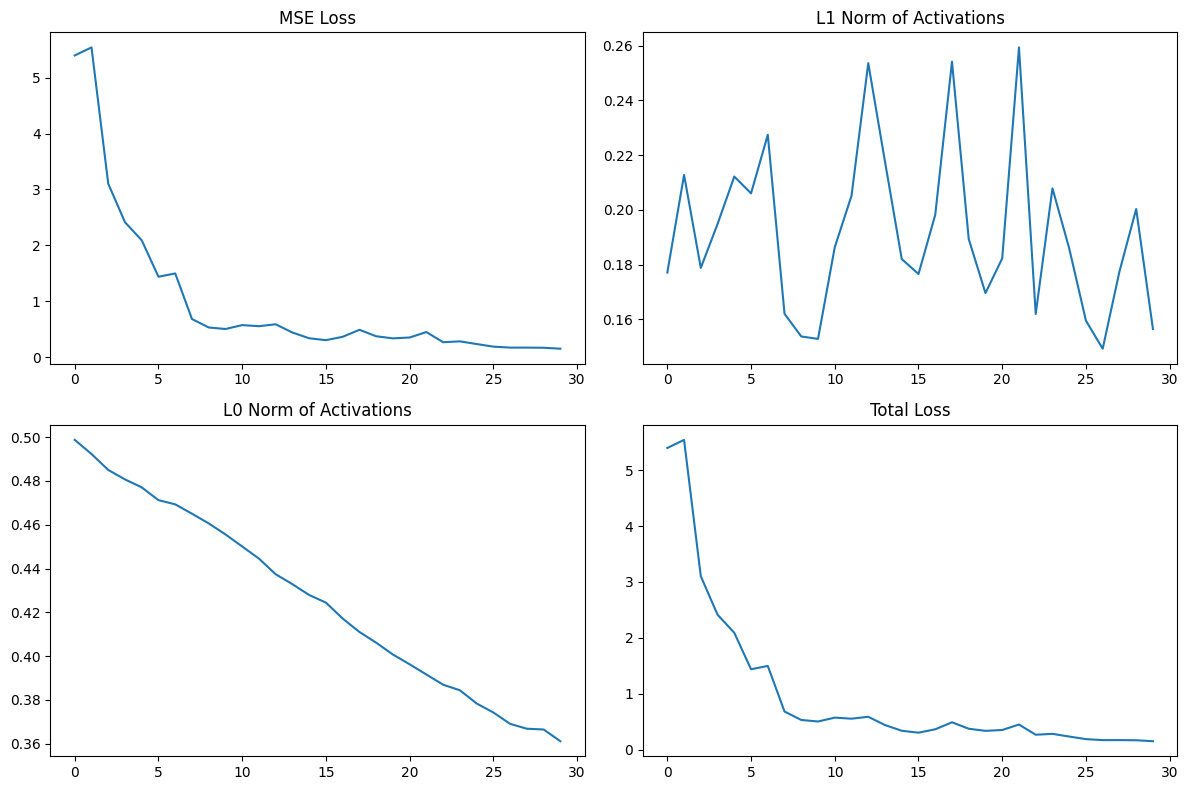

In [19]:
# plot the metrics
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(metrics['mse'])
plt.title('MSE Loss')
plt.subplot(2, 2, 2)
plt.plot(metrics['l1'])
plt.title('L1 Norm of Activations')
plt.subplot(2, 2, 3)
plt.plot(metrics['l0'])
plt.title('L0 Norm of Activations')
plt.subplot(2, 2, 4)
plt.plot(metrics['loss'])
plt.title('Total Loss')
plt.tight_layout()
plt.show()

In [25]:
for i, row in df.iterrows():
    if i == 2:
        break
    text = row['text']
    activations = model.run_with_cache(text, names_filter='blocks.3.hook_resid_post')[1]['blocks.3.hook_resid_post'][0].cpu()
    with torch.no_grad():
        f = SAE.encoder(activations)
    print(f[0])

tensor([0.0000, 0.0000, 1.5720,  ..., 0.0000, 0.0000, 0.0000])
tensor([0.0000, 0.0000, 1.5720,  ..., 0.0000, 0.0000, 0.0000])


In [23]:
df.head()

,text
0,"The very Republic is threatened, if involved t..."
1,"Hard to see, the dark side is. Discover who th..."
2,"With this Naboo queen you must stay, Qui-Gon. ..."
3,May the Force be with you.
4,(Cont'd) Master Qui-Gon more to say have you?


In [26]:
all_tokens = []
all_feature_acts = []
all_contexts = []

with torch.no_grad():
    for text in df.text:
        _, cache = model.run_with_cache(text, names_filter='blocks.3.hook_resid_post')
        acts = cache['blocks.3.hook_resid_post'][0].cpu()
        f = SAE.encoder(acts)
        
        tokens = model.to_str_tokens(text)
        
        for token_idx in range(len(tokens)):
            all_tokens.append(tokens[token_idx])
            all_feature_acts.append(f[token_idx])
            all_contexts.append(text)
        
        del cache

all_feature_acts = torch.stack(all_feature_acts)  # (total_tokens, 4096)
print(f"Total tokens: {len(all_tokens)}")
print(f"Feature activations shape: {all_feature_acts.shape}")

Total tokens: 1837
Feature activations shape: torch.Size([1837, 4096])


In [27]:
def inspect_feature(feature_idx, k=10):
    acts = all_feature_acts[:, feature_idx]
    top_vals, top_idxs = acts.topk(k)
    
    print(f"Feature {feature_idx} — top {k} activating tokens:\n")
    for val, idx in zip(top_vals, top_idxs):
        token = all_tokens[idx]
        context = all_contexts[idx]
        print(f"  {val:.3f}  token={repr(token):>15s}   context: {context[:80]}")

# try a few features
inspect_feature(2)
print()
inspect_feature(100)

Feature 2 — top 10 activating tokens:

  2.977  token=            '.'   context:  A great Jedi Master, you have become, Qui-Gon Jinn. Your apprentice I gratefull
  2.959  token=            '.'   context: Qui-Gon's defiance I sense in you. Need that, you do not. Agree, the council doe
  2.942  token=            '.'   context: The Chosen One the boy may be; nevertheless, grave danger I fear in his training
  2.895  token=            '.'   context:  Faith in your new apprentice, misplaced may be, as is your faith in the dark si
  2.890  token=            '.'   context:  Destroy you I will, just as Master Kenobi, your apprentice will destroy.
  2.882  token=            '.'   context:  If a special session of Congress there is, easier for us to enter the Jedi Temp
  2.871  token=            '.'   context: With this Naboo queen you must stay, Qui-Gon. Protect her.
  2.850  token=            '.'   context:  The secret of the Ancient Order of the Whills, he studied. How to commune with 
  2.83